# Animation
The purpose of this Jupyter Notebook is to present a challenging step-by-step example of how to create an animation.
If you don't have any experience with animations, it's better to start with a simpler example.

## 1 What should I know before I start?
- How to implement functions in Python.
- How to deal with arrays and mathematical functions in `numpy`.
- How to generate grafics with `pyplot` from `matplotlib`.

## 2 Packages
The following packages are used to display images:

In [1]:
from IPython.display import Image, HTML

## 3 What is an animation?
An animation consits of a sequence of images.
Each single image is called a frame.
Consecutive images are shown with a certain frequency.
This frequency is called frame rate and is specified in hertz.

<b>ToDo:</b> Insert a picture for better explanation!

## 4 A challenging example: The analog clock

<div class="alert alert-block alert-warning">
    
<b>Example</b>

We want to simulate an analog clock as shown in the figure below.

</div>

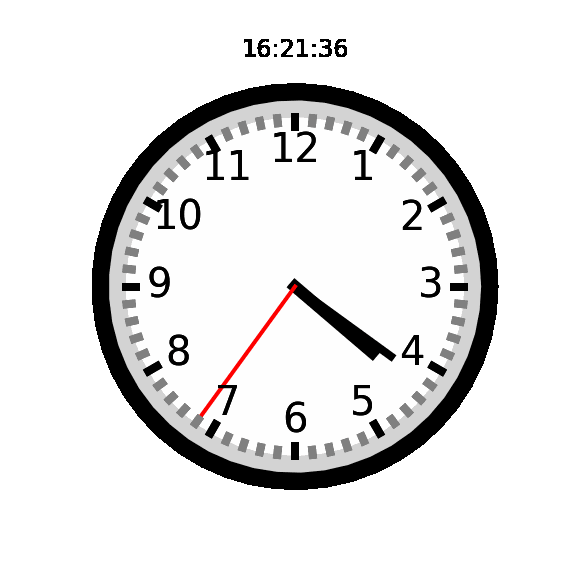

In [2]:
Image('images/25-animation-clock.gif', width=576, height=576)

## 5 Build the animation
The animation is bulit step-by-step.
### 5.1 Create a figure
First, a figure is generated.
Every frame of the animation will be generated inside the same figure.
The variable `fig` will be used as a global variable.
At the moment the figure should not be displayed.
Calling the function [`matplotlib.pyplot.close()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.close.html) will hide the figure.

In [3]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(4, 4),dpi=144)
plt.close(fig)

Matplotlib is building the font cache; this may take a moment.


### 5.2 Animation concept
Most of the graphics are the same in every frame.
Therefore, we do not clear the graphic for each frame.
Instead, most of the graphics are retained.
Only the data of the clock hands in each frame are changed.
For this purpose, the animation is divided into two functions:
- The function for graphics initialization `init()` is only called once.
- The function for graphics update `frame()` is called for each single frame.

### 5.3 The `init()` function
During initialization the plots for the clock hands for hour, minute and second are just prepared.
The data of these plots are initialized with empty arrays.
Later on these data will be set accordingly to the actual time of the frame. 

In [4]:
import numpy as np

def init():
    
    # get axis of figure
    ax = fig.gca()
    
    # set axis properties
    ax.axis('equal')
    ax.axis('off')

    # background
    t = np.linspace(0.0,2.0*np.pi)
    x, y = np.cos(t), np.sin(t)
    ax.fill(1.2*x,1.2*y,'black',1.1*x,1.1*y,'lightgray',1.0*x,1.0*y,'white')
    
    # hour hand, minute hand, second hand
    ax.plot([],[],linewidth=6, color='black')
    ax.plot([],[],linewidth=4, color='black')
    ax.plot([],[],linewidth=2, color='red')  

    # ticks
    for tick in np.arange(60):
        if tick % 5 == 0:
            length = 0.06;
            width = 4.0;
            color = 'black'
        else:
            length = 0.03;
            width = 4.0;
            color = 'gray'
        t = np.pi/2.0-tick/30.0*np.pi
        x, y = np.cos(t), np.sin(t)
        ax.plot(np.array([1.0,1.0-length])*x,np.array([1.0,1.0-length])*y,linewidth=width,markersize=12,color=color)
    
    # numbers
    for number in np.arange(1,13):
        t = np.pi/2.0-number/6.0*np.pi
        x, y = np.cos(t), np.sin(t)
        ax.text(0.8*x,0.8*y,str(number),fontsize=20,horizontalalignment='center',verticalalignment='center')

### 5.4 The `frame()` function

The `datetime` package is used for time arithmetic.
The variable `initial_time` is set as a global variable with the start time of the animation.

In [5]:
import datetime
initial_time = datetime.datetime.now()

The `frame()` function is used to update the hands for hour, minute and second.
This function has a single input argument `second`which specifies the numer of seconds passed after the `ìnitial_time`. 

In [6]:
def frame(second):
    
    # get axis of figure
    ax = fig.gca()

    # increase initial_time by second
    time = initial_time + datetime.timedelta(0,int(second))
    ax.set_title(time.strftime("%H:%M:%S"))
    
    # hour hand
    t = np.pi/2.0-time.hour/6.0*np.pi-time.minute/360.0*np.pi
    x, y = np.cos(t), np.sin(t)
    hour_hand = ax.get_lines()[0]
    hour_hand.set_data(np.array([0.0,0.6])*x,np.array([0.0,0.6])*y)

    # minute hand
    t = np.pi/2.0-time.minute/30.0*np.pi
    x, y = np.cos(t), np.sin(t)
    minute_hand = ax.get_lines()[1]
    minute_hand.set_data(np.array([0.0,0.7])*x,np.array([0.0,0.7])*y)

    # second hand
    t = np.pi/2.0-time.second/30.0*np.pi
    x, y = np.cos(t), np.sin(t)
    second_hand = ax.get_lines()[2]
    second_hand.set_data(np.array([0.0,1.0])*x,np.array([0.0,1.0])*y)

### 5.5 Generate animation object
The animation object is generated with the `FuncAnimation()` function.
In order to generate a real time simulation the delay between frames is set to 1000 milliseconds.

In [7]:
import matplotlib.animation
ani = matplotlib.animation.FuncAnimation(fig, func=frame, init_func=init, frames=range(0,10) , interval=1000)

## 6 Display animation in Juypter Notebook
The function `to_jshtml()` represents the animation object as Java Script code embedded in HTML.
This can be directly integrated in the Jupyter Notebook with the function `HTML()` form `IPython.display`.

In [8]:
display(HTML(ani.to_jshtml()))

## 7 Save animation as a movie file
An animation may be saved as a movie in a file by drawing every frame.
A list of all installed writers on your system can be generated.

In [9]:
print(matplotlib.animation.writers.list())

['pillow', 'html']


A widely used data format to store animations are `.gif` files which can be generated with the `pillow` writer. 

In [10]:
ani.save('25-animation-clock.gif', writer='pillow')

If no apropriate writer is installed you may install ImageMagick.
ImageMagick is free software which runs on most operating systems.

In [11]:
# Instalation of ImageMagick, see https://imagemagick.org/index.php
#
# Windows
# see https://towardsdatascience.com/quick-code-exporting-matplotlib-animations-49cd0ecf32ba
#
# Google Colab
# !apt install imagemagick
#
# Mac OS
# !brew install imagemagick

## Literature
- https://youtu.be/3IsiOYbdzpU